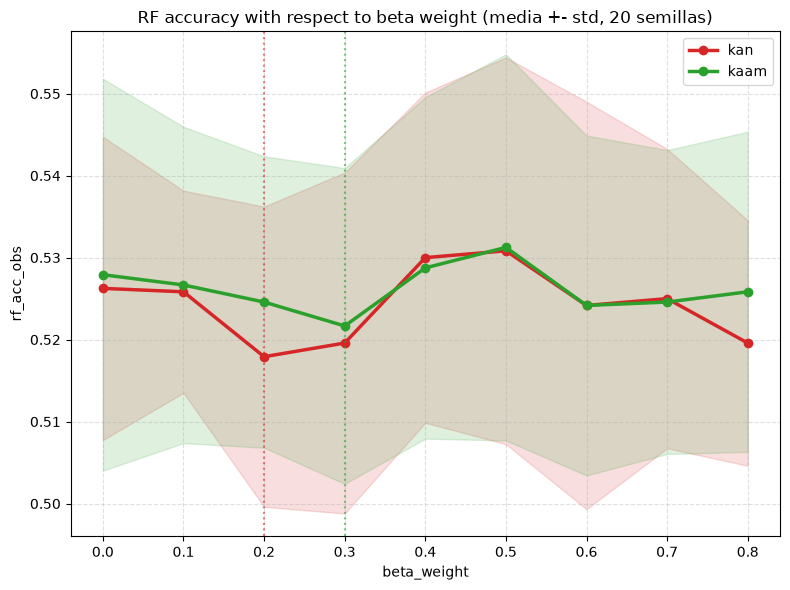

In [ ]:
# Grafico del barrido de beta: media +- std de rf_acc_obs sobre las 20 semillas
# (beta_sweep_results_por_semilla / beta0_sweep_results_por_semilla, celda anterior),
# incluyendo el punto Beta=0 (MSE puro, tambien promediado sobre las mismas 20 semillas).
#
# Nota: los notebooks Ruido_Aditivo_*.ipynb usan un eje Y secundario para Beta=1 (HSIC
# puro) porque su valor puede diferir mucho en escala del resto del barrido. Aqui Beta=0
# (MSE puro) es el analogo "extremo" (el otro punto fuera del barrido hybrid), pero su
# rf_acc_obs esta en un rango similar al de Beta in [0.1, 0.8] (ver celda anterior), asi
# que no hace falta esa complejidad: un unico eje con banda de +-std es suficiente. Si al
# ejecutar esto con datos reales Beta=0 resulta tener una escala muy distinta, se puede
# anadir el mismo truco de eje secundario que en Ruido_Aditivo_*.ipynb.
paleta_familia = {"kan": "tab:red", "kaam": "tab:green"}
betas_con_cero = [0.0] + betas

fig, ax = plt.subplots(figsize=(8, 6))
for family, color in paleta_familia.items():
    valores0 = list(beta0_sweep_results_por_semilla[family].values())
    y_mean = [float(np.mean([v["rf_acc_obs"] for v in valores0]))]
    y_std = [float(np.std([v["rf_acc_obs"] for v in valores0]))]
    for b in betas:
        valores = list(beta_sweep_results_por_semilla[family][b].values())
        y_mean.append(float(np.mean([v["rf_acc_obs"] for v in valores])))
        y_std.append(float(np.std([v["rf_acc_obs"] for v in valores])))
    y_mean = np.array(y_mean)
    y_std = np.array(y_std)

    ax.plot(betas_con_cero, y_mean, marker="o", linewidth=2.5, label=family, color=color, markersize=6)
    ax.fill_between(betas_con_cero, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)
    ax.axvline(beta_opt[family], linestyle=":", color=color, alpha=0.6)

ax.set_xlabel("beta_weight")
ax.set_ylabel("rf_acc_obs")
ax.set_title(f"RF accuracy with respect to beta weight (media +- std, {len(beta_sweep_seeds)} semillas)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xticks(betas_con_cero)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "sachs_hsic_beta_sweep.png"), dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Load and print the results
metrics = ['rf_acc_obs', 'mmd_obs', 'rf_acc_int', 'mmd_int', 'mse_cf', 'mae_cf']  # Metrics used for evaluation

results_table_all = []
for model_name in model_names:
    results_file = os.path.join(data_dir, f"sachs_results_{model_name}.pkl")
    if os.path.exists(results_file):
        with open(results_file, 'rb') as f:
            results = pickle.load(f)
        results_table_all.append([model_name] + [results[m + '_avg'] for m in metrics] + [results['training_time']])
    else:
        print(f"Results file {results_file} not found.")

print('\n\n Average results per model (Sachs, con beta HSIC optima incluida):')
print(tabulate(results_table_all, headers=['model'] + metrics + ['Time'], floatfmt=".4f", tablefmt="fancy_grid"))




 Average results per model (Sachs, con beta HSIC optima incluida):
╒═══════════╤══════════════╤═══════════╤══════════════╤═══════════╤══════════╤══════════╤══════════╕
│ model     │   rf_acc_obs │   mmd_obs │   rf_acc_int │   mmd_int │   mse_cf │   mae_cf │     Time │
╞═══════════╪══════════════╪═══════════╪══════════════╪═══════════╪══════════╪══════════╪══════════╡
│ kan       │       0.6000 │    0.0080 │       0.5653 │    0.0197 │   0.1145 │   0.0815 │ 105.3306 │
├───────────┼──────────────┼───────────┼──────────────┼───────────┼──────────┼──────────┼──────────┤
│ kaam      │       0.6083 │    0.0080 │       0.5687 │    0.0200 │   0.1164 │   0.0834 │ 124.4819 │
├───────────┼──────────────┼───────────┼──────────────┼───────────┼──────────┼──────────┼──────────┤
│ kan_hsic  │       0.6333 │    0.0079 │       0.5731 │    0.0197 │   0.1172 │   0.0824 │ 279.9231 │
├───────────┼──────────────┼───────────┼──────────────┼───────────┼──────────┼──────────┼──────────┤
│ kaam_hsic │       0.

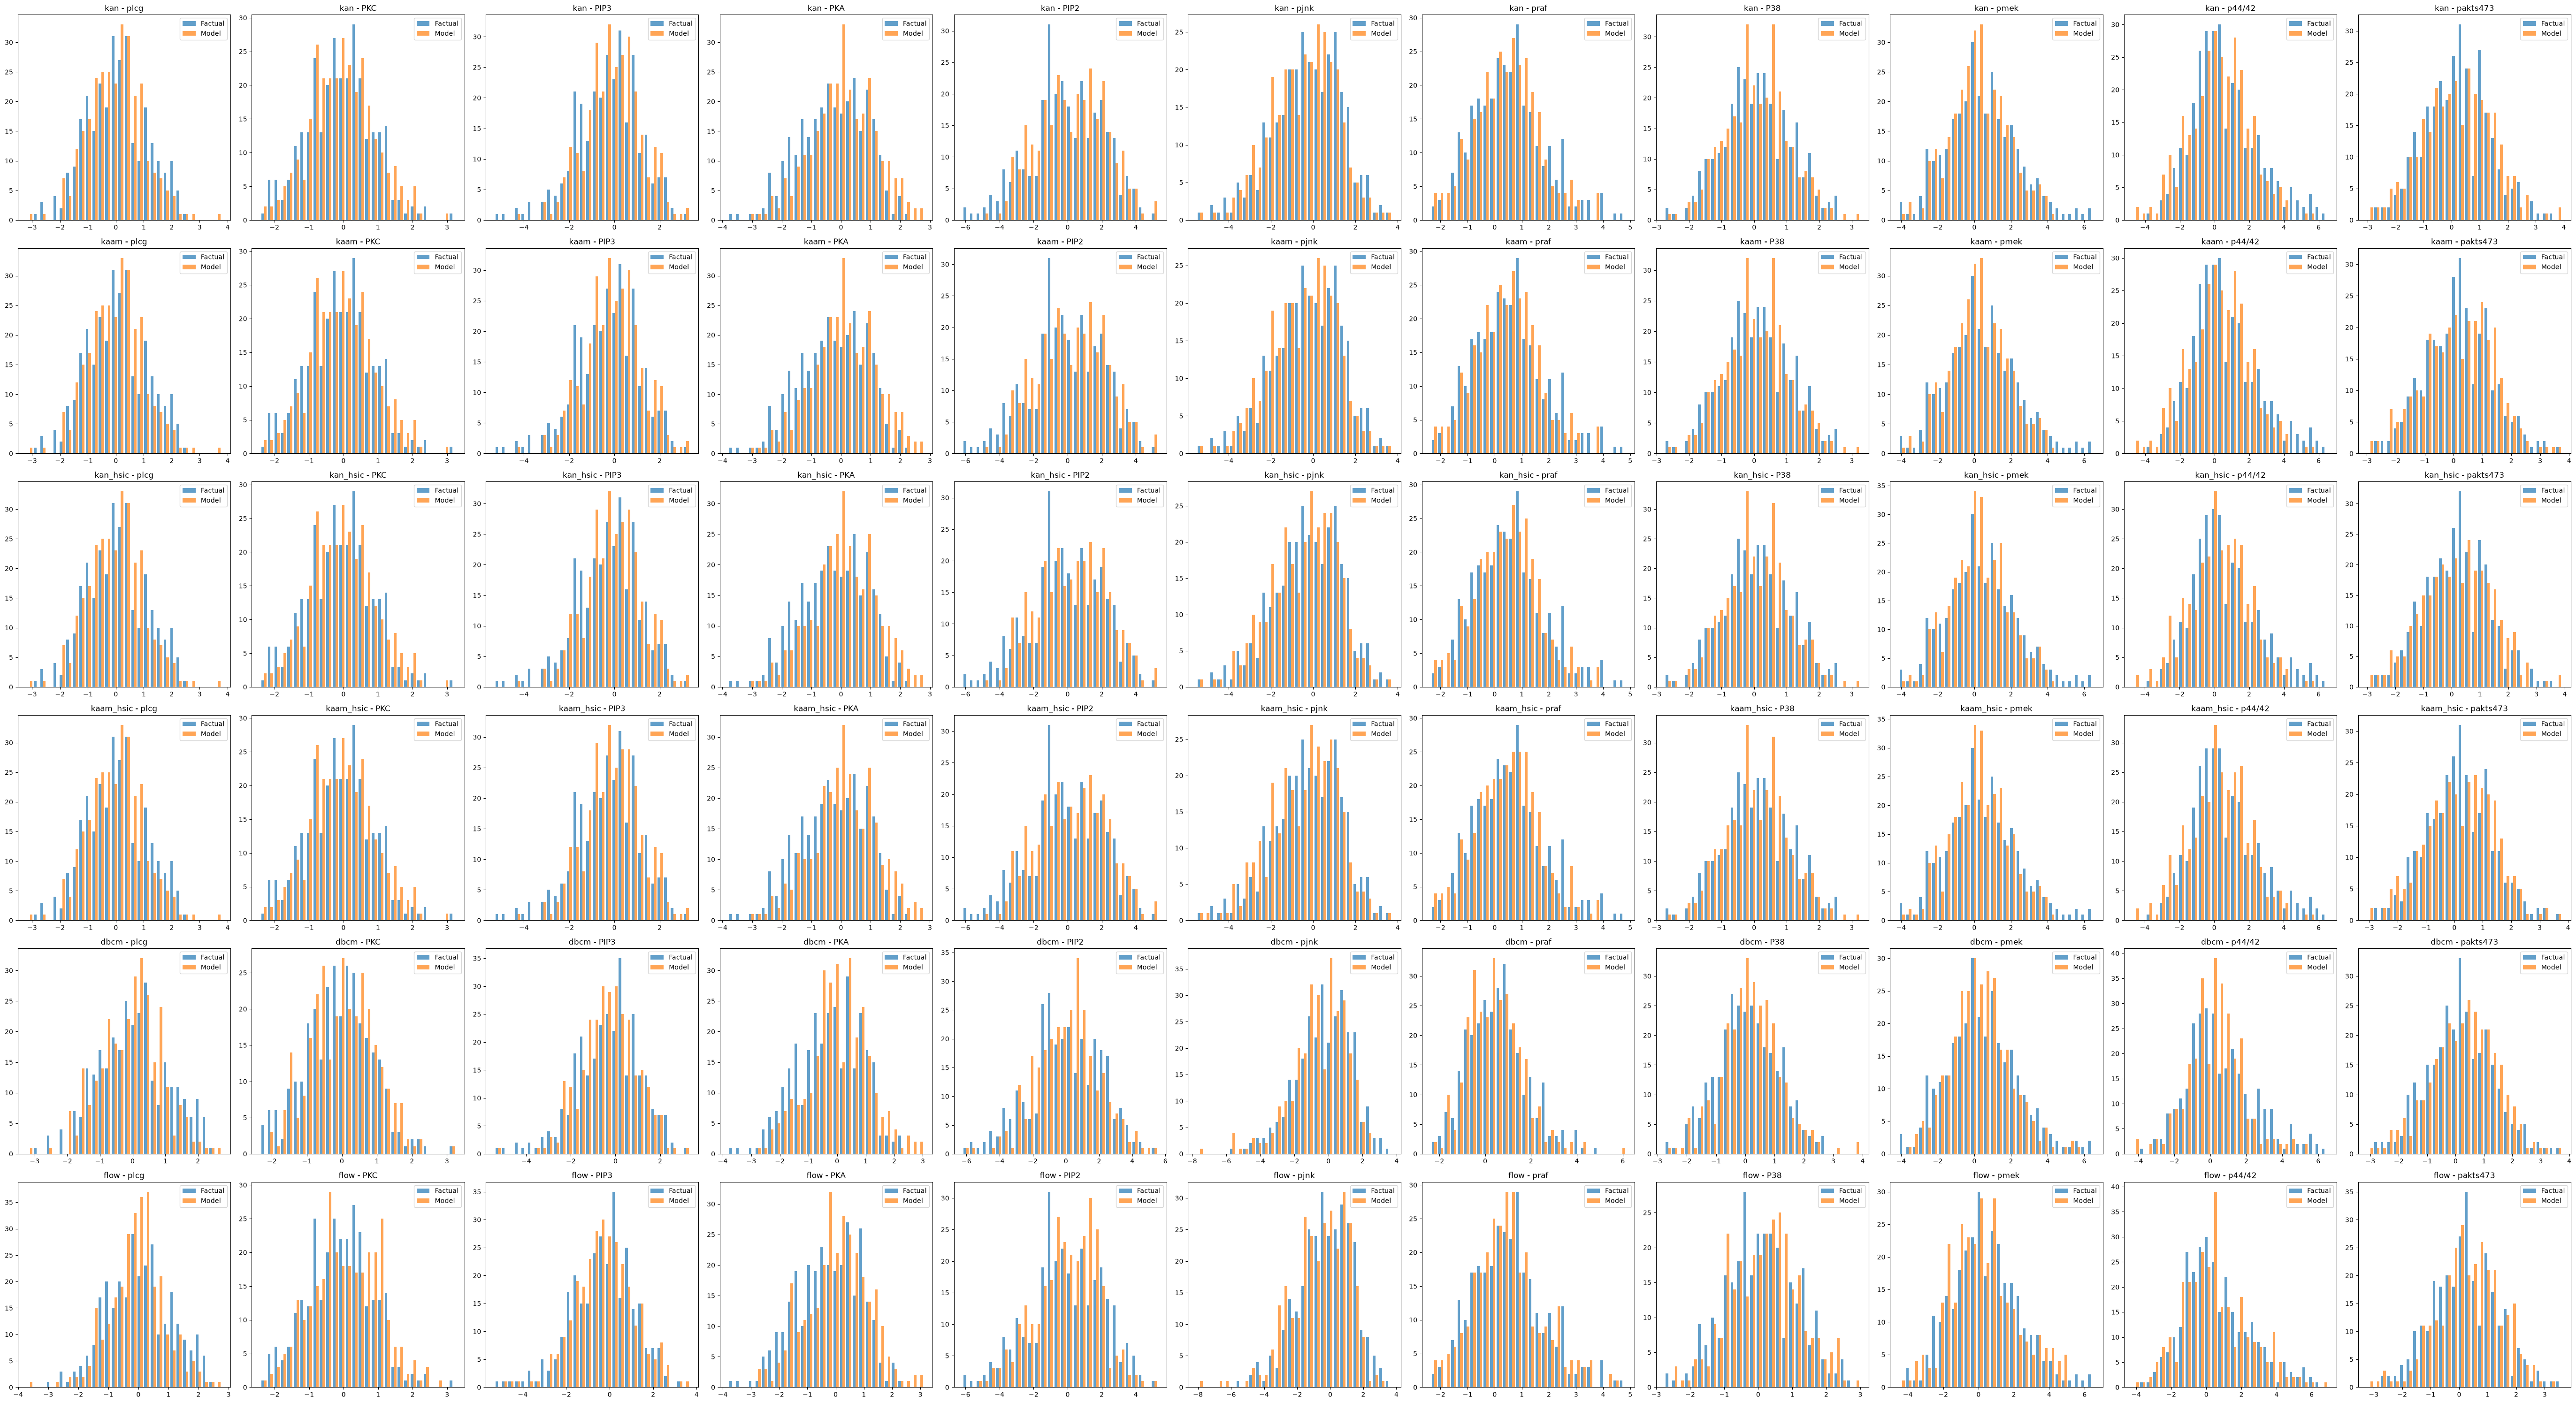

In [ ]:
# Show the distributions of observational samples for all models compared to the factual data
nodes = factual_eval.columns
plt.subplots(len(model_names), len(nodes), figsize=(5 * len(nodes), 5 * len(model_names)))
for i, node in enumerate(nodes):
    for j, model_name in enumerate(model_names):
        obs_model = pd.read_csv(os.path.join(samples_dir, f"sachs_obs_samples_{model_name}.csv"))
        plt.subplot(len(model_names), len(nodes), j * len(nodes) + i + 1)
        plt.hist([factual_eval[node], obs_model[node]], bins=30, label=['Factual', 'Model'], alpha=0.7)
        plt.title(f'{model_name} - {node}')
        plt.legend(loc='best')
plt.tight_layout()
plt.show()



===== Formulas extraidas (kaam) =====
Extracted formula for node plcg using kaam model: N/A
Extracted formula for node PKC using kaam model: N/A
Extracted formula for node PIP3 using kaam model: -0.1901*plcg**2 + 0.7384*plcg + 0.0463
Extracted formula for node PKA using kaam model: 0.3299*tanh(2.166*PKC - 0.0188) + 0.0153
Extracted formula for node PIP2 using kaam model: 0.6512*PIP3 + 1.0355*plcg + 0.2152
Extracted formula for node pjnk using kaam model: -0.1911*PKA**2 - 0.8732*PKA + 0.0243*PKC**4 + 0.087*PKC**3 - 0.2042*PKC**2 - 0.7898*PKC - 0.1165
Extracted formula for node praf using kaam model: 0.2732*PKA**2 - 0.1726*PKA - 0.0879*PKC**4 + 0.0043*PKC**3 + 0.477*PKC**2 - 0.3311*PKC - 0.0784
Extracted formula for node P38 using kaam model: -0.0285*PKA**2 - 0.1123*PKA + 0.0572*PKC**2 + 0.1064*PKC + 0.0338
Extracted formula for node pmek using kaam model: -0.1593*PKA**2 - 0.9934*PKA + 0.0138*PKC**2 - 0.0852*PKC + 0.1542*praf**2 + 0.0412*praf + 0.1085
Extracted formula for node p44/42 u

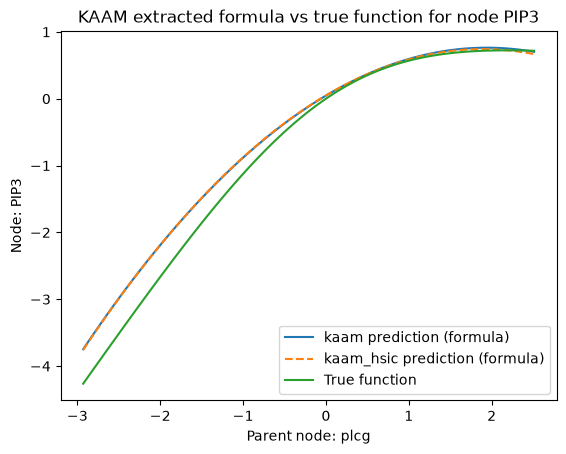

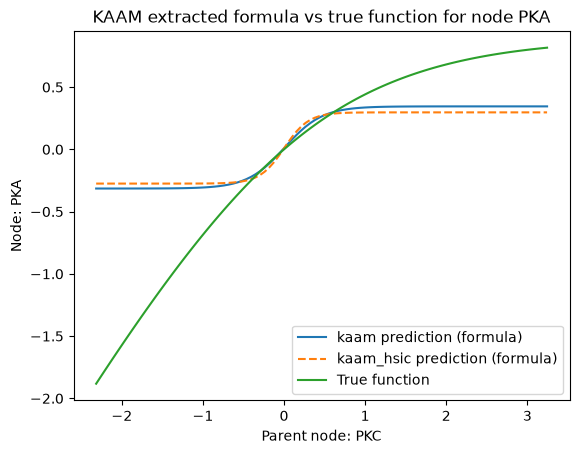

In [ ]:
# Load the kaam / kaam_hsic results (extracted formulas, MAE, and per-node formula/true-function curves)
kaam_formula_results = {}
for kaam_variant in ['kaam', 'kaam_hsic']:
    with open(os.path.join(data_dir, f"sachs_results_{kaam_variant}.pkl"), 'rb') as f:
        kaam_formula_results[kaam_variant] = pickle.load(f)

for kaam_variant in ['kaam', 'kaam_hsic']:
    results = kaam_formula_results[kaam_variant]
    print(f"\n===== Formulas extraidas ({kaam_variant}) =====")
    for node in factual_eval.columns:
        print(f'Extracted formula for node {node} using {kaam_variant} model: {results.get(f"kaam_formula_{node}", "N/A")}')

    print(f'\nMAE results for {kaam_variant} formulas on SACHS dataset:')
    for node in factual_eval.columns:
        print(f'Node: {node}, MAE: {results.get(f"mae_{node}", "N/A")}')
    print(f'Global MAE: {results.get("mae", "N/A")}')

# Plot kaam vs kaam_hsic extracted formulas against the true function, for single-parent nodes
kaam_results = kaam_formula_results['kaam']
kaam_hsic_results = kaam_formula_results['kaam_hsic']
for node in factual_eval.columns:
    if graph_sachs.in_degree(node) == 1:  # Single parent nodes are the ones we are visualizing
        parent_node = list(graph_sachs.predecessors(node))[0]
        x_vals_ref = kaam_results.get(f'x_vals_{node}', kaam_hsic_results.get(f'x_vals_{node}'))
        if x_vals_ref is None:
            continue
        if f'x_vals_{node}' in kaam_results:
            plt.plot(kaam_results[f'x_vals_{node}'], kaam_results[f'formula_pred_{node}'], label='kaam prediction (formula)')
        if f'x_vals_{node}' in kaam_hsic_results:
            plt.plot(kaam_hsic_results[f'x_vals_{node}'], kaam_hsic_results[f'formula_pred_{node}'], label='kaam_hsic prediction (formula)', linestyle='--')
        plt.plot(x_vals_ref,
                 structural_equations['additive'][node](np.zeros((len(x_vals_ref), 1)), x_vals_ref.reshape(-1, 1)),
                 label='True function')
        plt.xlabel(f'Parent node: {parent_node}')
        plt.ylabel(f'Node: {node}')
        plt.title(f'KAAM extracted formula vs true function for node {node}')
        plt.legend()
        plt.show()


 Parents of child node PIP3: {'plcg'}; we will compute interventions on plcg.
Full formula for Estimated Treatment Effect of node PIP3 using kaam model: -0.1901*plcg**2 + 0.7384*plcg + 0.0463
ATE formula estimated for child node PIP3 using kaam model when intervening on node plcg with values (-1.0, 1.0): 1.47680664062500
Full formula for Estimated Treatment Effect of node PIP3 using kaam_hsic model: -0.1937*plcg**2 + 0.7325*plcg + 0.0495
ATE formula estimated for child node PIP3 using kaam_hsic model when intervening on node plcg with values (-1.0, 1.0): 1.46499633789063


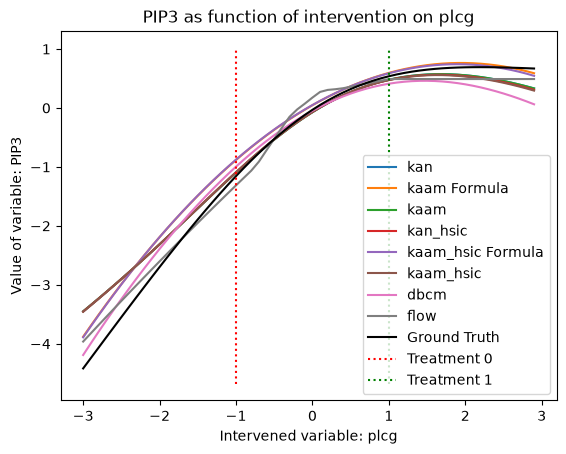

 Parents of child node PKA: {'PKC'}; we will compute interventions on PKC.
Full formula for Estimated Treatment Effect of node PKA using kaam model: 0.3299*tanh(2.166*PKC - 0.0188) + 0.0153
ATE formula estimated for child node PKA using kaam model when intervening on node PKC with values (-1.0, 1.0): 0.642669859374606
Full formula for Estimated Treatment Effect of node PKA using kaam_hsic model: 0.286*tanh(3.3294*PKC - 0.0097) + 0.0111
ATE formula estimated for child node PKA using kaam_hsic model when intervening on node PKC with values (-1.0, 1.0): 0.570532810718164


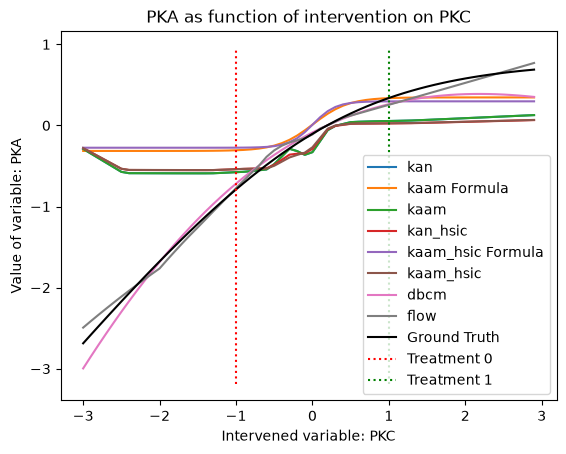

 Parents of child node PIP2: {'PIP3', 'plcg'}; we will compute interventions on PIP3.
Full formula for Estimated Treatment Effect of node PIP2 using kaam model: 0.6512*PIP3 + 1.0355*plcg + 0.2152
ATE formula estimated for child node PIP2 using kaam model when intervening on node PIP3 with values (-1.0, 1.0): 1.30239868164063
Full formula for Estimated Treatment Effect of node PIP2 using kaam_hsic model: 0.6514*PIP3 + 1.0426*plcg + 0.2169
ATE formula estimated for child node PIP2 using kaam_hsic model when intervening on node PIP3 with values (-1.0, 1.0): 1.30279541015625


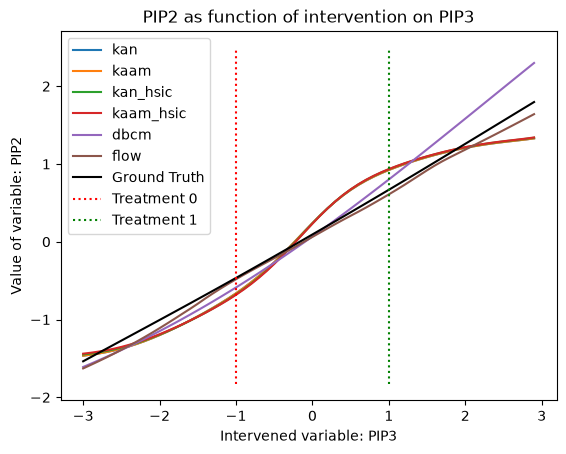

 Parents of child node pjnk: {'PKA', 'PKC'}; we will compute interventions on PKA.
Full formula for Estimated Treatment Effect of node pjnk using kaam model: -0.1911*PKA**2 - 0.8732*PKA + 0.0243*PKC**4 + 0.087*PKC**3 - 0.2042*PKC**2 - 0.7898*PKC - 0.1165
ATE formula estimated for child node pjnk using kaam model when intervening on node PKA with values (-1.0, 1.0): -1.74639892578125
Full formula for Estimated Treatment Effect of node pjnk using kaam_hsic model: -0.2304*PKA**2 - 0.905*PKA + 0.034*PKC**4 + 0.0776*PKC**3 - 0.2815*PKC**2 - 0.759*PKC - 0.0323
ATE formula estimated for child node pjnk using kaam_hsic model when intervening on node PKA with values (-1.0, 1.0): -1.80999755859375


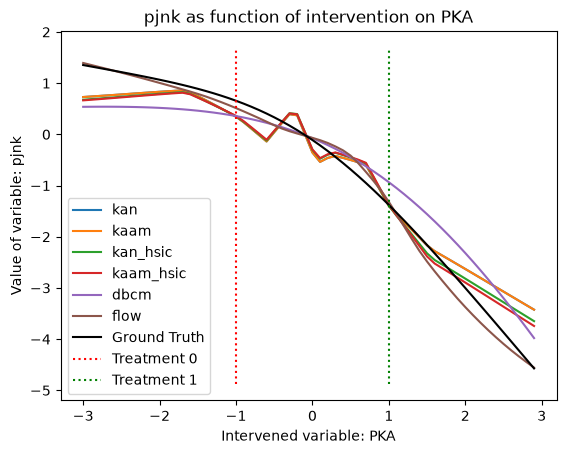

 Parents of child node praf: {'PKA', 'PKC'}; we will compute interventions on PKA.
Full formula for Estimated Treatment Effect of node praf using kaam model: 0.2732*PKA**2 - 0.1726*PKA - 0.0879*PKC**4 + 0.0043*PKC**3 + 0.477*PKC**2 - 0.3311*PKC - 0.0784
ATE formula estimated for child node praf using kaam model when intervening on node PKA with values (-1.0, 1.0): -0.345199584960938
Full formula for Estimated Treatment Effect of node praf using kaam_hsic model: 0.2714*PKA**2 - 0.1839*PKA - 0.0846*PKC**4 + 0.0103*PKC**3 + 0.4626*PKC**2 - 0.3333*PKC - 0.0706
ATE formula estimated for child node praf using kaam_hsic model when intervening on node PKA with values (-1.0, 1.0): -0.367801666259766


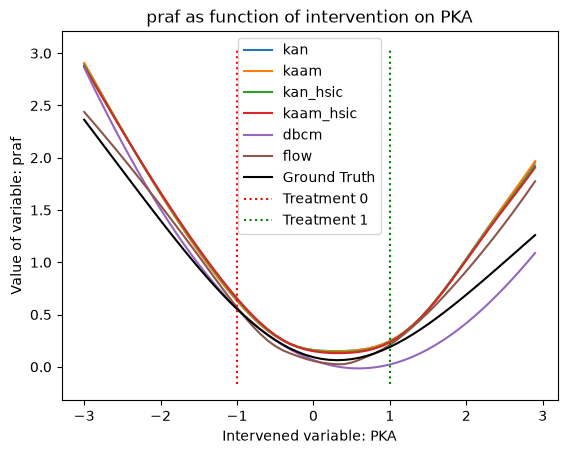

 Parents of child node P38: {'PKA', 'PKC'}; we will compute interventions on PKA.
Full formula for Estimated Treatment Effect of node P38 using kaam model: -0.0285*PKA**2 - 0.1123*PKA + 0.0572*PKC**2 + 0.1064*PKC + 0.0338
ATE formula estimated for child node P38 using kaam model when intervening on node PKA with values (-1.0, 1.0): -0.224599838256836
Full formula for Estimated Treatment Effect of node P38 using kaam_hsic model: -0.0291*PKA**2 - 0.1118*PKA + 0.0563*PKC**2 + 0.1046*PKC + 0.0297
ATE formula estimated for child node P38 using kaam_hsic model when intervening on node PKA with values (-1.0, 1.0): -0.223600387573242


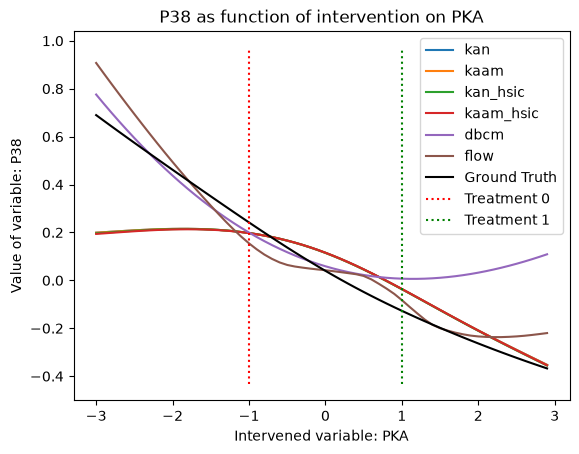

 Parents of child node pmek: {'PKA', 'praf', 'PKC'}; we will compute interventions on PKA.
Full formula for Estimated Treatment Effect of node pmek using kaam model: -0.1593*PKA**2 - 0.9934*PKA + 0.0138*PKC**2 - 0.0852*PKC + 0.1542*praf**2 + 0.0412*praf + 0.1085
ATE formula estimated for child node pmek using kaam model when intervening on node PKA with values (-1.0, 1.0): -1.98680114746094
Full formula for Estimated Treatment Effect of node pmek using kaam_hsic model: -0.1672*PKA**2 - 0.9956*PKA + 0.015*PKC**2 - 0.085*PKC + 0.1546*praf**2 + 0.0412*praf + 0.113
ATE formula estimated for child node pmek using kaam_hsic model when intervening on node PKA with values (-1.0, 1.0): -1.99119567871094


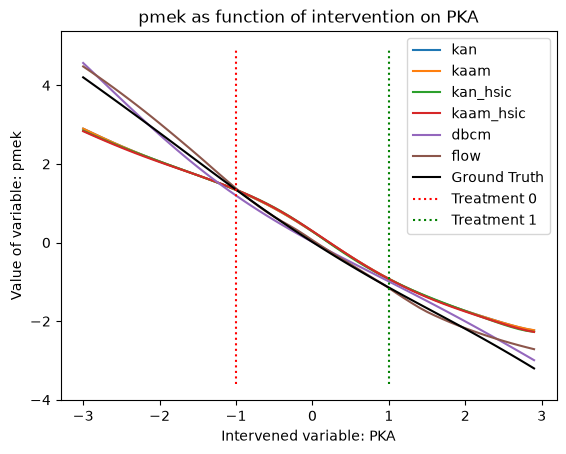

 Parents of child node p44/42: {'pmek', 'PKA', 'praf', 'PKC'}; we will compute interventions on pmek.
Full formula for Estimated Treatment Effect of node p44/42 using kaam model: -0.7189*PKA + 0.0319*pmek**2 + 0.3823*pmek + 0.1667
ATE formula estimated for child node p44/42 using kaam model when intervening on node pmek with values (-1.0, 1.0): 0.764602661132813
Full formula for Estimated Treatment Effect of node p44/42 using kaam_hsic model: -0.715*PKA + 0.0302*pmek**2 + 0.3882*pmek + 0.1756
ATE formula estimated for child node p44/42 using kaam_hsic model when intervening on node pmek with values (-1.0, 1.0): 0.776397705078125


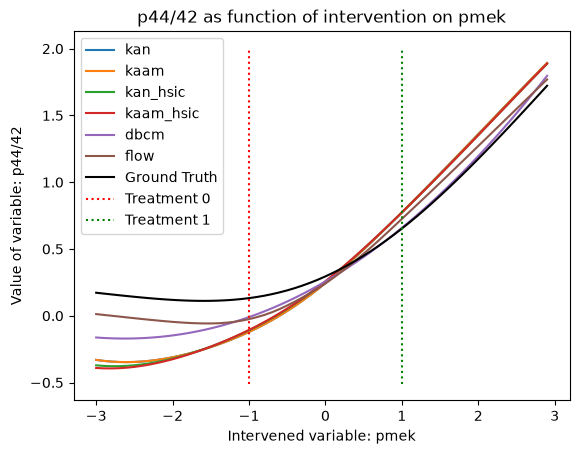

 Parents of child node pakts473: {'PKA', 'PKC', 'pmek', 'p44/42', 'praf'}; we will compute interventions on PKA.
Full formula for Estimated Treatment Effect of node pakts473 using kaam model: 0.0001*p44/42**4 + 0.0022*p44/42**3 + 0.0114*p44/42**2 - 0.0213*p44/42 + 0.459*tanh(4.3269*PKA - 2.2564) + 0.297
ATE formula estimated for child node pakts473 using kaam model when intervening on node PKA with values (-1.0, 1.0): 0.903623475403818
Full formula for Estimated Treatment Effect of node pakts473 using kaam_hsic model: 0.0001*p44/42**4 + 0.0021*p44/42**3 + 0.013*p44/42**2 - 0.0179*p44/42 + 0.4555*tanh(4.5694*PKA - 2.3917) + 0.2907
ATE formula estimated for child node pakts473 using kaam_hsic model when intervening on node PKA with values (-1.0, 1.0): 0.899455611565011


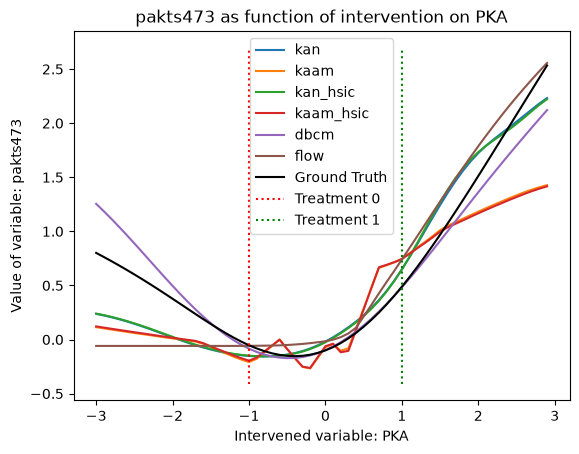

╒═══════════════╤══════════════╤═══════════════════╤════════════════════╤═════════════╤═════════════╤═════════════════╕
│ Parent node   │ Child node   │ Model             │   ATE Ground Truth │   ATE Model │   Abs Error │   Rel Error (%) │
╞═══════════════╪══════════════╪═══════════════════╪════════════════════╪═════════════╪═════════════╪═════════════════╡
│ plcg          │ PIP3         │ kan               │             1.6939 │      1.5749 │      0.1190 │          7.0277 │
├───────────────┼──────────────┼───────────────────┼────────────────────┼─────────────┼─────────────┼─────────────────┤
│ plcg          │ PIP3         │ kaam              │             1.6939 │      1.5749 │      0.1190 │          7.0272 │
├───────────────┼──────────────┼───────────────────┼────────────────────┼─────────────┼─────────────┼─────────────────┤
│ plcg          │ PIP3         │ kaam formula      │             1.6939 │      1.4768 │      0.2171 │         12.8175 │
├───────────────┼──────────────┼────────

In [ ]:
# ATE example on a single variable: formula vs ground truth vs each model
intervention_values = (-1.0, 1.0)

ate_table = []

for child_node in factual_eval.columns:
    n_parents = graph_sachs.in_degree(child_node)
    if n_parents > 0:  # Only when there exists at least a parent!
        parent_nodes = nx.ancestors(graph_sachs, child_node)
        parent_node = f'{list(parent_nodes)[0]}'  # We will only plot results intervening on the first parent
        print(f' Parents of child node {child_node}: {parent_nodes}; we will compute interventions on {parent_node}.')
        parent_cf_values = {parent_node: {'cf_gt_0': None, 'cf_gt_1': None, 'gt_ate': None}}
        for node_, value_, d_ in inter_vector:
            if parent_node == node_:
                if np.abs(value_ - intervention_values[0]) < 1e-3:
                    parent_cf_values[parent_node]['cf_gt_0'] = d_[child_node]
                if np.abs(value_ - intervention_values[1]) < 1e-3:
                    parent_cf_values[parent_node]['cf_gt_1'] = d_[child_node]
        parent_cf_values[parent_node]['gt_ate'] = np.mean(parent_cf_values[parent_node]['cf_gt_1'].to_numpy()) - np.mean(parent_cf_values[parent_node]['cf_gt_0'].to_numpy())

        for model_name in model_names:
            with open(os.path.join(data_dir, f'sachs_cf_eval_{model_name}.pkl'), 'rb') as f:
                results_cf = pickle.load(f)
            for node_, value_, d_ in results_cf:
                if parent_node == node_:
                    if np.abs(value_ - intervention_values[0]) < 1e-3:
                        parent_cf_values[parent_node][f'cf_{model_name}_0'] = d_[child_node]
                    if np.abs(value_ - intervention_values[1]) < 1e-3:
                        parent_cf_values[parent_node][f'cf_{model_name}_1'] = d_[child_node]
            parent_cf_values[parent_node][f'{model_name}_ate'] = np.mean(parent_cf_values[parent_node][f'cf_{model_name}_1'].to_numpy()) - np.mean(parent_cf_values[parent_node][f'cf_{model_name}_0'].to_numpy())
            abs_ate_error = np.abs(parent_cf_values[parent_node]['gt_ate'] - parent_cf_values[parent_node][f'{model_name}_ate'])
            rel_ate_erro = 100 * abs_ate_error / np.abs(parent_cf_values[parent_node]['gt_ate'])
            ate_table.append([parent_node, child_node, model_name, parent_cf_values[parent_node]['gt_ate'], parent_cf_values[parent_node][f'{model_name}_ate'], abs_ate_error, rel_ate_erro])

            if model_name in ('kaam', 'kaam_hsic'):
                # Now, create a symbolic function using the formulas extracted by kaam / kaam_hsic
                child_node_formula = kaam_formula_results[model_name].get(f'kaam_formula_{child_node}', None)
                if child_node_formula is None:
                    print(f'No formula for node {child_node} in {model_name} model')
                else:
                    kaam_ate_formula = child_node_formula.subs(parent_node, intervention_values[1]) - child_node_formula.subs(parent_node, intervention_values[0])
                    print(f'Full formula for Estimated Treatment Effect of node {child_node} using {model_name} model: {child_node_formula}')
                    print(f'ATE formula estimated for child node {child_node} using {model_name} model when intervening on node {parent_node} with values {intervention_values}: {kaam_ate_formula}')
                    ate_formula_val = float(kaam_ate_formula)
                    abs_ate_error_f = np.abs(parent_cf_values[parent_node]['gt_ate'] - ate_formula_val)
                    rel_ate_erro_f = 100 * abs_ate_error_f / np.abs(parent_cf_values[parent_node]['gt_ate'])
                    ate_table.append([parent_node, child_node, f'{model_name} formula', parent_cf_values[parent_node]['gt_ate'], ate_formula_val, abs_ate_error_f, rel_ate_erro_f])

                    if n_parents == 1:  # We can only plot this for single-parent nodes
                        kaam_cf_vals = [float(child_node_formula.subs(parent_node, x)) for x in list(cf_vector_values)]
                        plt.plot(cf_vector_values, kaam_cf_vals, label=f'{model_name} Formula')

            # Plot the expected effect curve for this model
            cf_vals_ordered = []
            for value_o in list(cf_vector_values):
                for node_, value_, d_ in results_cf:
                    if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                        cf_vals_ordered.append(np.mean(d_[child_node].to_numpy()))
            plt.plot(cf_vector_values, cf_vals_ordered, label=model_name)

        # Now, let's obtain the ATE plot using the structural equations (ground truth)
        if child_node in structural_equations['additive']:
            cf_gt_vals = []
            for value_o in list(cf_vector_values):
                for node_, value_, d_ in inter_vector:
                    if parent_node == node_ and np.abs(value_ - value_o) < 1e-3:
                        cf_gt_vals.append(np.mean(d_[child_node].to_numpy()))
            cf_gt_vals = np.array(cf_gt_vals)
            plt.plot(cf_vector_values, cf_gt_vals, label='Ground Truth', color='black')
            y_min, y_max = plt.ylim()
            plt.vlines(intervention_values[0], ymin=y_min, ymax=y_max, color='red', linestyle=':', label='Treatment 0')
            plt.vlines(intervention_values[1], ymin=y_min, ymax=y_max, color='green', linestyle=':', label='Treatment 1')
            plt.xlabel(f'Intervened variable: {parent_node}')
            plt.ylabel(f'Value of variable: {child_node}')
            plt.title(f'{child_node} as function of intervention on {parent_node}')
            plt.legend()
            plt.show()

print(tabulate(ate_table,
               headers=['Parent node', 'Child node', 'Model', 'ATE Ground Truth', 'ATE Model', 'Abs Error', 'Rel Error (%)'],
               floatfmt=".4f", tablefmt="fancy_grid"))

# Create an average ATE table, for each model compute the avg and std of the ATE error
ate_table_avg = []
for row_model in model_names + ['kaam formula', 'kaam_hsic formula']:
    values_to_avg = [row[5:] for row in ate_table if row[2] == row_model]
    if not values_to_avg:
        continue
    values_to_avg = np.array(values_to_avg)
    mean = np.mean(values_to_avg, axis=0)
    std = np.std(values_to_avg, axis=0)
    ate_table_avg.append([row_model] + [f'{mean[i]:.2f} ({std[i]:.2f})' for i in range(len(mean))])

print(tabulate(ate_table_avg, headers=['Model name', 'Abs error', 'Rel error (%)'], floatfmt=".4f", tablefmt="fancy_grid"))


In [ ]:
# # ATE metrics evaluated on a grid for all possible interventions
# formula_model_names = ['kaam_formula', 'kaam_hsic_formula']


# def compute_ate_per_int_node(child_node):
#     print(f'Computing ATE over the node {child_node}')
#     parent_nodes = nx.ancestors(graph_sachs, child_node)
#     ate_vals = {}
#     for parent_node in parent_nodes:
#         ate_vals[parent_node] = {}
#         for model_name in model_names + ['ground_truth'] + formula_model_names:
#             ate_vals[parent_node][model_name] = {}
#             child_node_formula = None
#             if model_name in formula_model_names:
#                 base_variant = model_name.replace('_formula', '')
#                 child_node_formula = kaam_formula_results[base_variant].get(f'kaam_formula_{child_node}', None)
#                 if child_node_formula is None:
#                     print(f'No formula for node {child_node} ({base_variant})')

#             if model_name in model_names:
#                 with open(os.path.join(data_dir, f'sachs_cf_eval_{model_name}.pkl'), 'rb') as f:
#                     results_cf = pickle.load(f)

#             for value0 in list(cf_vector_values):
#                 ate_vals[parent_node][model_name][value0] = {}
#                 for value1 in list(cf_vector_values):
#                     if model_name == 'ground_truth':
#                         cf_gt_0 = None
#                         cf_gt_1 = None
#                         for node_, value_, d_ in inter_vector:
#                             if parent_node == node_:
#                                 if np.abs(value_ - value0) < 1e-3:
#                                     cf_gt_0 = np.mean(d_[child_node].to_numpy())
#                                 if np.abs(value_ - value1) < 1e-3:
#                                     cf_gt_1 = np.mean(d_[child_node].to_numpy())
#                         ate_vals[parent_node][model_name][value0][value1] = cf_gt_1 - cf_gt_0
#                     elif model_name in formula_model_names:
#                         if child_node_formula is None:
#                             ate = None
#                         else:
#                             ate = float(child_node_formula.subs(parent_node, value1) - child_node_formula.subs(parent_node, value0))
#                         ate_vals[parent_node][model_name][value0][value1] = ate
#                     else:
#                         cf_model_0 = None
#                         cf_model_1 = None
#                         for node_, value_, d_ in results_cf:
#                             if parent_node == node_:
#                                 if np.abs(value_ - value0) < 1e-3:
#                                     cf_model_0 = np.mean(d_[child_node].to_numpy())
#                                 else:
#                                     cf_model_1 = np.mean(d_[child_node].to_numpy())
#                         ate_vals[parent_node][model_name][value0][value1] = cf_model_0 - cf_model_1
#     print(f'Finished the ATE computation over the node {child_node}')
#     return child_node, ate_vals


# out = Parallel(n_jobs=n_jobs)(delayed(compute_ate_per_int_node)(child_node) for child_node in factual_eval.columns)

# ate_results_evaluation = {}
# for child_node, ate_node in out:
#     ate_results_evaluation[child_node] = ate_node

# labels = model_names + formula_model_names
# ate_errors = []
# for model_name in labels:
#     error = []
#     for child_node in factual_eval.columns:
#         for parent_node in ate_results_evaluation[child_node].keys():
#             for value0 in list(cf_vector_values):
#                 for value1 in list(cf_vector_values):
#                     ate_gt = ate_results_evaluation[child_node][parent_node]['ground_truth'][value0][value1]
#                     ate_model = ate_results_evaluation[child_node][parent_node][model_name][value0][value1]
#                     if ate_model is None:
#                         continue
#                     error.append(np.abs(ate_gt - ate_model))
#     ate_errors.append(error)

# plt.figure(figsize=(10, 6))
# plt.boxplot(ate_errors)
# plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=30)
# plt.ylabel('Absolute Error')
# plt.title('Absolute Error for ATE in all nodes')
# plt.ylim(bottom=1e-2)
# plt.yscale('log')
# plt.grid()
# plt.tight_layout()
# plt.savefig(os.path.join(figures_dir, "sachs_hsic_ate_boxplot.png"), dpi=200, bbox_inches="tight")
# plt.show()
